In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [2]:
df = pd.read_csv("../data/customer_segmented.csv")

df.head()

,name,age,gender,education,income,country,purchase_frequency,annual_spending,cluster,segment
0,Teresa Williams MD,42,Female,High School,53936,Slovenia,0.9,13227.120,1,Regular
1,Christine Myers,49,Female,Master,82468,Aruba,0.6,12674.040,0,Premium
2,Dwayne Moreno,55,Male,Bachelor,56941,Cyprus,0.3,5354.115,2,Budget
3,Amy Norton,24,Female,Bachelor,60651,Palau,0.2,2606.510,2,Budget
4,Tonya Adams,64,Male,Master,81884,Zambia,0.9,18984.780,0,Premium


In [3]:
features = [
    "age",
    "income",
    "purchase_frequency",
    "annual_spending"
]

X = df[features].copy()

X.head()

,age,income,purchase_frequency,annual_spending
0,42,53936,0.9,13227.120
1,49,82468,0.6,12674.040
2,55,56941,0.3,5354.115
3,24,60651,0.2,2606.510
4,64,81884,0.9,18984.780


In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [5]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

In [6]:
silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

print("Silhouette Score:", round(silhouette, 4))

Silhouette Score: 0.2658


In [7]:
davies_bouldin = davies_bouldin_score(
    X_scaled,
    cluster_labels
)

print(
    "Davies-Bouldin Index:",
    round(davies_bouldin, 4)
)

Davies-Bouldin Index: 1.3313


In [8]:
calinski = calinski_harabasz_score(
    X_scaled,
    cluster_labels
)

print(
    "Calinski-Harabasz Score:",
    round(calinski, 4)
)

Calinski-Harabasz Score: 429.578


In [9]:
evaluation_results = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Score"
    ],
    "Value": [
        round(silhouette, 4),
        round(davies_bouldin, 4),
        round(calinski, 4)
    ]
})

evaluation_results

,Metric,Value
0,Silhouette Score,0.2658
1,Davies-Bouldin Index,1.3313
2,Calinski-Harabasz Score,429.5780


In [10]:
cluster_distribution = pd.Series(
    cluster_labels
).value_counts().sort_index()

cluster_distribution

0    292
1    262
2    446
Name: count, dtype: int64

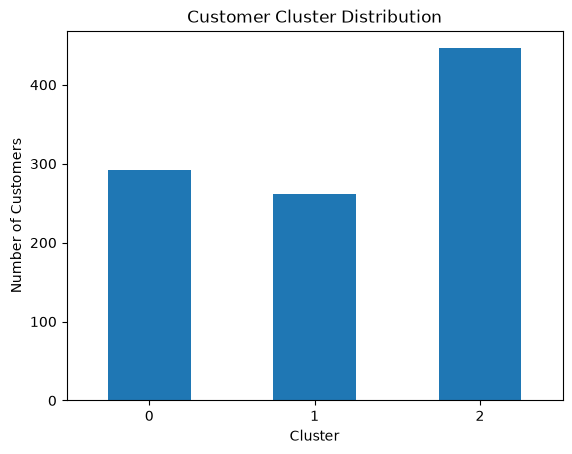

In [11]:
import matplotlib.pyplot as plt

cluster_distribution.plot(
    kind="bar"
)

plt.title("Customer Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

results = []

for k in range(2, 7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    results.append({
        "K": k,
        "Silhouette Score": silhouette_score(
            X_scaled,
            labels
        ),
        "Davies-Bouldin Index": davies_bouldin_score(
            X_scaled,
            labels
        ),
        "Calinski-Harabasz Score": calinski_harabasz_score(
            X_scaled,
            labels
        )
    })

comparison = pd.DataFrame(results)

comparison.round(4)

,K,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,2,0.3060,1.2940,543.3342
1,3,0.2658,1.3313,429.5780
2,4,0.2588,1.3485,419.7002
3,5,0.2570,1.2266,398.9207
4,6,0.2670,1.1520,403.8735


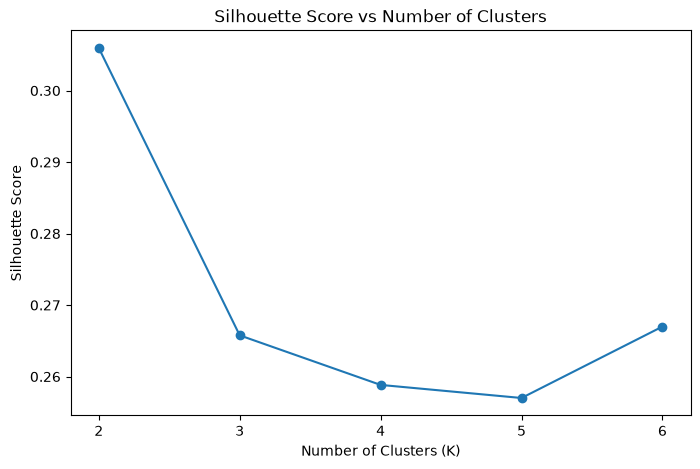

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    comparison["K"],
    comparison["Silhouette Score"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.xticks(comparison["K"])

plt.show()

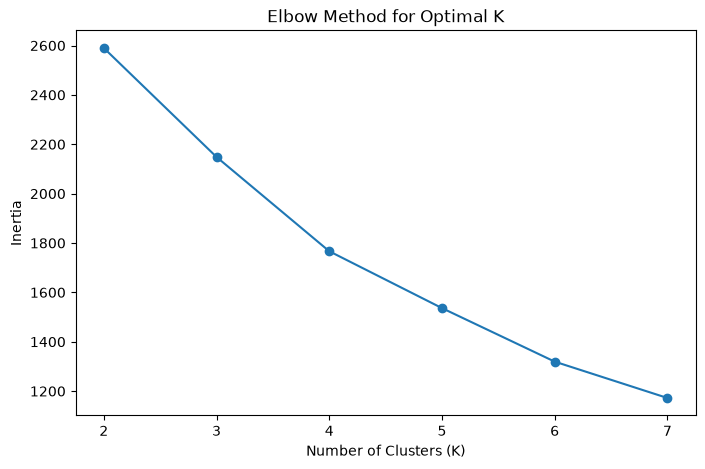

In [14]:
import matplotlib.pyplot as plt

inertias = []

k_values = range(2, 8)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertias.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(list(k_values))

plt.show()

## Final Model Selection

The K-Means model was evaluated using the Elbow Method,
Silhouette Score, Davies-Bouldin Index, and
Calinski-Harabasz Score.

The evaluation of K values from 2 to 6 showed that K=3
provides a suitable balance between cluster quality,
model simplicity, and business interpretability.

Although K=2 achieved a higher Silhouette Score, it would
only produce two customer groups and would not support the
required Premium, Regular, and Budget segmentation strategy.

Therefore, K=3 was selected for the final CustoLens AI model.